In [ ]:
# Customer Churn Prediction Project

print("Customer Churn Prediction Project")
print("Starting Data Science project...")

Customer Churn Prediction Project
Starting Data Science project...


In [ ]:
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries installed and imported successfully!")

Libraries installed and imported successfully!


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape:
(7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
print("Churn counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again
print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:")
print(df.shape)

Dataset shape after cleaning:
(7032, 21)


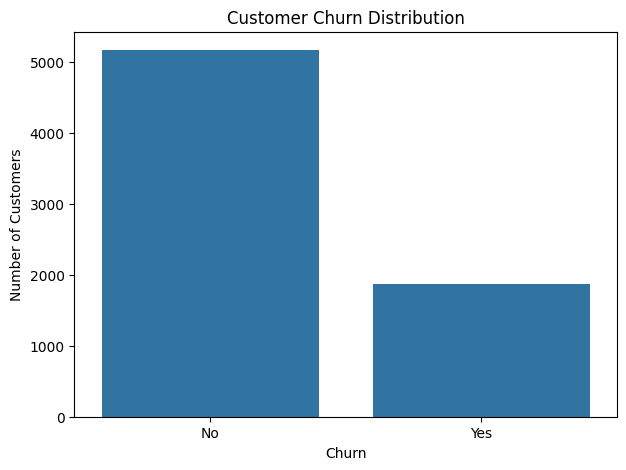

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage.round(2))

Customer Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


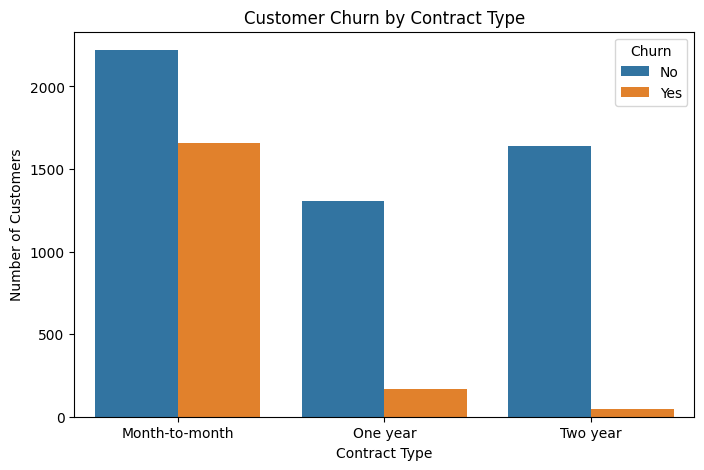

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


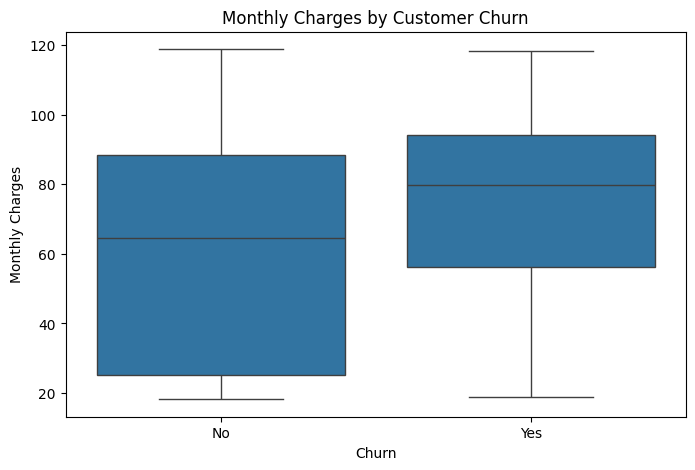

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
average_charges = df.groupby("Churn")["MonthlyCharges"].mean()

print("Average Monthly Charges:")
print(average_charges.round(2))

Average Monthly Charges:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


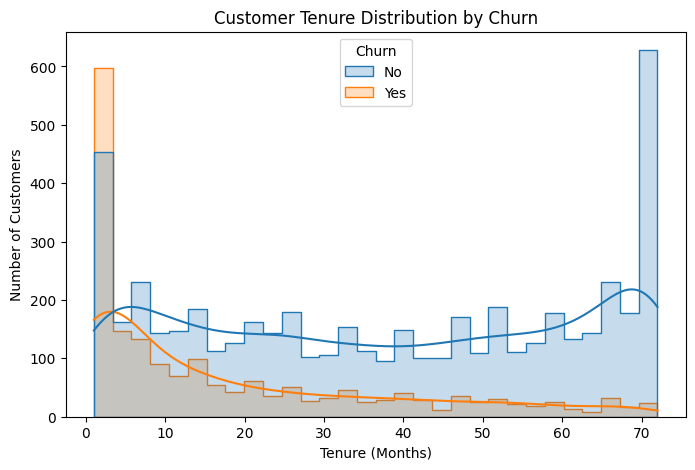

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
average_tenure = df.groupby("Churn")["tenure"].mean()

print("Average Customer Tenure:")
print(average_tenure.round(2))

Average Customer Tenure:
Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64


In [ ]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
df = df.drop("customerID", axis=1)

print("Customer ID removed.")
print(df.head())

Customer ID removed.
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1          

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
print("\nFirst 5 rows:")
df_encoded.head()

Encoded dataset shape: (7032, 31)

First 5 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (7032, 30)
Target (y): (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.31 %


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
dt_pred = decision_tree.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 77.83 %


In [ ]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
print("Model Comparison")
print("---------------------------")
print("Logistic Regression:", round(accuracy * 100, 2), "%")
print("Decision Tree:      ", round(dt_accuracy * 100, 2), "%")

Model Comparison
---------------------------
Logistic Regression: 80.31 %
Decision Tree:       77.83 %


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
rf_pred = random_forest.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 78.96 %


In [ ]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
print("MODEL COMPARISON")
print("==============================")
print("Logistic Regression:", round(accuracy * 100, 2), "%")
print("Decision Tree:      ", round(dt_accuracy * 100, 2), "%")
print("Random Forest:      ", round(rf_accuracy * 100, 2), "%")

MODEL COMPARISON
Logistic Regression: 80.31 %
Decision Tree:       77.83 %
Random Forest:       78.96 %


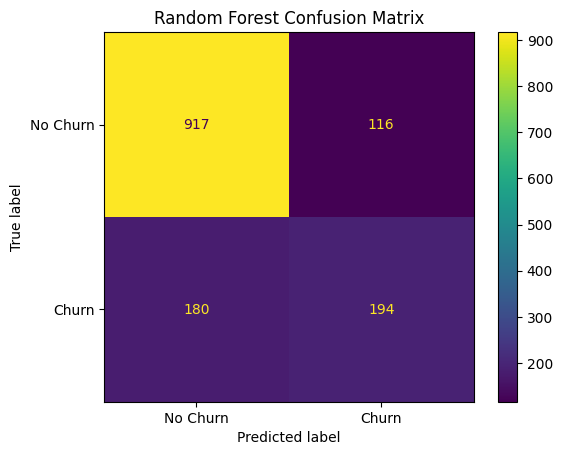

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest ROC-AUC:", round(roc_auc, 3))

Random Forest ROC-AUC: 0.816


In [ ]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

Top 15 Most Important Features:
                           Feature  Importance
3                     TotalCharges    0.191435
1                           tenure    0.171020
2                   MonthlyCharges    0.168400
10     InternetService_Fiber optic    0.039481
28  PaymentMethod_Electronic check    0.037416
25               Contract_Two year    0.030529
4                      gender_Male    0.029332
13              OnlineSecurity_Yes    0.028157
26            PaperlessBilling_Yes    0.025536
19                 TechSupport_Yes    0.024114
5                      Partner_Yes    0.023682
15                OnlineBackup_Yes    0.022932
24               Contract_One year    0.022836
0                    SeniorCitizen    0.021035
6                   Dependents_Yes    0.019846


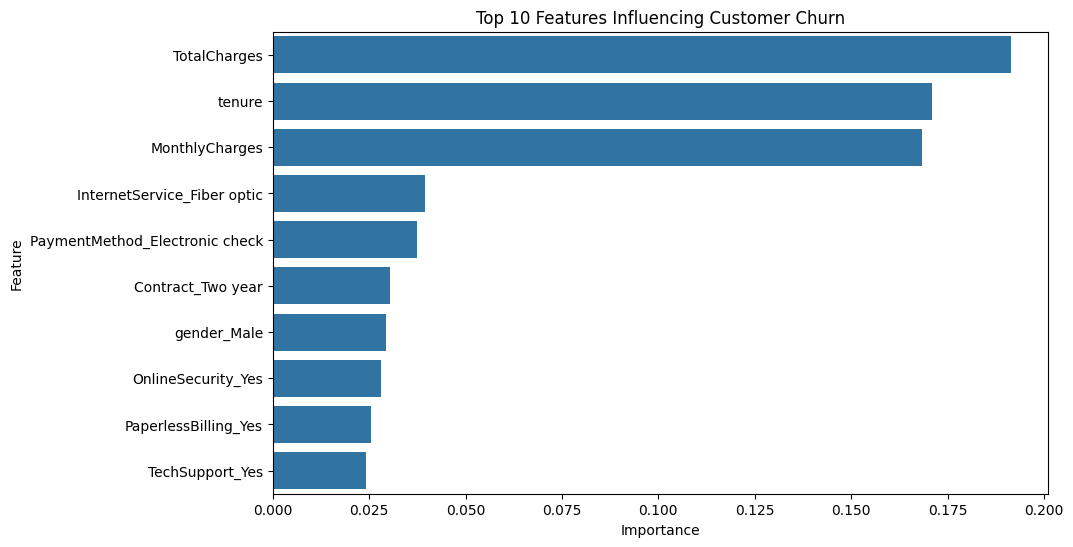

In [ ]:
# Visualise top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# Compare our three machine-learning models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results["Accuracy (%)"] = model_results["Accuracy"] * 100

model_results = model_results.drop("Accuracy", axis=1)

print(model_results.round(2))

                 Model  Accuracy (%)
0  Logistic Regression         80.31
1        Decision Tree         77.83
2        Random Forest         78.96


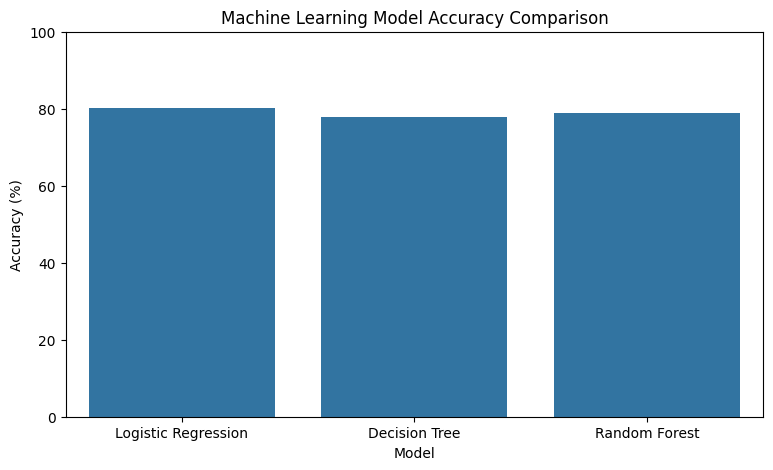

In [ ]:
# Visualise model accuracy

plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [ ]:
# Save cleaned dataset

df.to_csv("cleaned_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
